# 04 — Anomaly Detection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mohamed-Al-Saudi/EnergySavvy-AI-Project/blob/main/notebooks/04_anomaly_detection.ipynb)


**Goal:** Detect unusual consumption relative to a defined or learned normal pattern.

**Input:** `data/household_power/processed/household_power_hourly.parquet` + `models/forecast_rf.pkl` (from 03)

**Output:** `reports/results/anomaly_report.csv` + `reports/figures/anomaly_*.png`

**Idea:** If the forecasting model from 03 learns normal behavior, then large prediction errors = anomalies. We combine **residual analysis + Isolation Forest**.

Each detected anomaly also gets a `message` that explains:
- **what** was detected (spike / drop / unusual hour),
- **when** it happened,
- **how far** it deviated from the expected pattern,
- **which detectors** flagged it (residual z-score, isolation forest, or both),
- a short list of **possible causes** (never a definite appliance — just candidates to check).

## 0. Setup & Load Data
Load hourly data. This cell is Colab-safe: it loads from GitHub raw if file not found locally.


In [8]:
from pathlib import Path
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestRegressor
PROCESSED = Path("data/household_power/processed/household_power_hourly.parquet")
MODELS_DIR = Path("models")
RESULTS_DIR = Path("reports/results")
FIG_DIR = Path("reports/figures")
for d in [RESULTS_DIR, FIG_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
# Colab-safe loading
if not PROCESSED.exists():
    URL = "https://raw.githubusercontent.com/Mohamed-Al-Saudi/EnergySavvy-AI-Project/main/data/household_power/processed/household_power_hourly.parquet"
    print(f"Processed not found locally, loading from GitHub raw...")
    df = pd.read_parquet(URL)
else:
    df = pd.read_parquet(PROCESSED)
df.index = pd.to_datetime(df.index)
print(f"Loaded: {df.shape}")
df.head()

Processed not found locally, loading from GitHub raw...
Loaded: (34589, 7)


,Global_active_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,unmeasured_Wh
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,234.643875,18.099998,0.0,19.0,607.0,1907.733398
2006-12-16 18:00:00,3.632200,234.580154,15.600000,0.0,403.0,1012.0,2217.199951
2006-12-16 19:00:00,3.400233,233.232498,14.503333,0.0,86.0,1001.0,2313.233398
2006-12-16 20:00:00,3.268567,234.071503,13.916667,0.0,0.0,1007.0,2261.566650
2006-12-16 21:00:00,3.056467,237.158661,13.046666,0.0,25.0,1033.0,1998.466675


## 1. Feature Engineering (Same as 03)
To reuse the forecasting model, we must recreate exactly the same features:
- **Time features:** hour, dayofweek, month, is_weekend
- **Lags:** lag_1 (1h ago), lag_24 (same hour yesterday), lag_168 (same hour last week)
- **Rolling:** roll_24_mean, roll_24_std (mean/std of last 24h)

This ensures our model predictions are consistent.

In [9]:
target = 'Global_active_power'
df_t = df[[target]].asfreq('h')
# time features
df_t['hour'] = df_t.index.hour
df_t['dayofweek'] = df_t.index.dayofweek
df_t['month'] = df_t.index.month
df_t['is_weekend'] = (df_t.index.dayofweek >= 5).astype(int)
# lag features - the memory of the model
for lag in [1,2,3,24,168]:
    df_t[f'lag_{lag}'] = df_t[target].shift(lag)
# rolling features
df_t['roll_24_mean'] = df_t[target].shift(1).rolling(24).mean()
df_t['roll_24_std'] = df_t[target].shift(1).rolling(24).std()
df_t = df_t.dropna()
X = df_t.drop(columns=[target])
y = df_t[target]
print(f"After feature engineering: {df_t.shape}")
print(f"Features: {X.columns.tolist()}")
df_t.head()

After feature engineering: (34421, 12)
Features: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'roll_24_mean', 'roll_24_std']


,Global_active_power,hour,dayofweek,month,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_168,roll_24_mean,roll_24_std
datetime,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,17,5,12,1,4.349100,4.049100,3.757967,1.496800,4.222889,2.934890,0.990187
2006-12-23 18:00:00,3.879400,18,5,12,1,5.452533,4.349100,4.049100,2.686967,3.632200,3.099712,1.066674
2006-12-23 19:00:00,4.117833,19,5,12,1,3.879400,5.452533,4.349100,3.938167,3.400233,3.149397,1.074356
2006-12-23 20:00:00,4.181400,20,5,12,1,4.117833,3.879400,5.452533,3.536067,3.268567,3.156883,1.080699
2006-12-23 21:00:00,3.288433,21,5,12,1,4.181400,4.117833,3.879400,4.548667,3.056467,3.183772,1.098426


## 2. Load Forecasting Model from 03
The model learned normal consumption. If actual consumption is far from prediction, it's anomalous.
If `forecast_rf.pkl` not found (e.g. running in Colab without uploading model), we train a quick RF on 70% train

In [10]:
model_path = MODELS_DIR / "forecast_rf.pkl"
try:
    rf = joblib.load(model_path)
    print(f"Loaded model: {model_path}")
except Exception as e:
    print(f"Model not found ({e}), training quick RF...")
    split = int(len(df_t)*0.7)
    rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
    rf.fit(X.iloc[:split], y.iloc[:split])
# Predict normal behavior
df_t['y_pred'] = rf.predict(X)
df_t['residual'] = df_t[target] - df_t['y_pred']
df_t['abs_error'] = df_t['residual'].abs()
df_t[['Global_active_power','y_pred','residual']].tail()

Model not found ([Errno 2] No such file or directory: 'models/forecast_rf.pkl'), training quick RF...


,Global_active_power,y_pred,residual
datetime,,,
2010-11-26 17:00:00,1.725900,1.176054,0.549846
2010-11-26 18:00:00,1.573467,1.924611,-0.351144
2010-11-26 19:00:00,1.659333,1.594446,0.064887
2010-11-26 20:00:00,1.163700,1.860761,-0.697061
2010-11-26 21:00:00,0.934667,1.180323,-0.245656


## 3. Anomaly Strategy 1: Residual + Z-Score (Main Method)

**Logic:**
- `residual = y_true − y_pred`
- If the model is good, residual ≈ 0. Large residual ≡ model surprised ≡ anomaly.
- Rolling Z-score: `z = (residual − rolling_mean) / rolling_std` over last week (24×7 hours).
- Flag if `|z| > 3` (3σ) **OR** `abs_error > 2 × RMSE`.

This is adaptive: the threshold changes with volatility, not a fixed kW value.

Each flagged hour gets a **general message** describing the anomaly event itself, plus a short list of **possible causes to check** (not asserted as the cause).

In [11]:
window = 24 * 7

df_t['resid_roll_mean'] = df_t['residual'].rolling(window).mean()
df_t['resid_roll_std']  = df_t['residual'].rolling(window).std()
df_t['z_score'] = (df_t['residual'] - df_t['resid_roll_mean']) / (df_t['resid_roll_std'] + 1e-8)

RMSE_proxy = df_t['abs_error'].quantile(0.9)

df_t['is_anomaly_resid'] = (
    (df_t['z_score'].abs() > 3.0) | (df_t['abs_error'] > 2 * RMSE_proxy)
)

print(f"RMSE proxy (90th pct): {RMSE_proxy:.3f}")
print(f"Anomalies (residual method): {df_t['is_anomaly_resid'].sum()} / {len(df_t)} "
      f"({df_t['is_anomaly_resid'].mean()*100:.2f}%)")

# General anomaly message (devices listed as possible causes only)
def build_resid_message(row):
    kw       = row[target]
    y_pred   = row['y_pred']
    residual = row['residual']
    z        = row.get('z_score', 0.0)
    hour     = int(row['hour'])
    dow      = int(row['dayofweek'])
    day_str  = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][dow]
    time_str = f"{hour:02d}:00"

    # Type of deviation
    if residual > 0:
        kind = "spike (consumption higher than expected)"
    else:
        kind = "drop (consumption lower than expected)"

    # Period of day (context, not a claim)
    if   0 <= hour < 6:   period = "overnight"
    elif 6 <= hour < 10:  period = "morning"
    elif 10 <= hour < 17: period = "daytime"
    elif 17 <= hour < 22: period = "evening peak"
    else:                 period = "late evening"

    # Possible causes — framed as candidates, not conclusions
    if period == "overnight" and residual > 0:
        causes = "an appliance left running, a defrost/standby cycle, or a heating/cooling device activating"
    elif period == "morning" and residual > 0:
        causes = "several appliances starting at once, or an overlapping high-power routine"
    elif period == "daytime" and residual > 0:
        causes = "a large appliance running (laundry, cooking, cooling), or several mid-load devices overlapping"
    elif period == "evening peak" and residual > 0:
        causes = "multiple high-power appliances running simultaneously during peak hours"
    elif residual < 0:
        causes = "a usually-active device was off, or the household was unoccupied during this hour"
    else:
        causes = "an unusual combination of loads not seen in the training period"

    return (
        f"[{row.name:%Y-%m-%d %H:%M}] Residual anomaly detected on "
        f"{day_str} {time_str} ({period}): {kind}. "
        f"Actual {kw:.2f} kW vs expected {y_pred:.2f} kW "
        f"(Δ {residual:+.2f} kW, |z|={abs(z):.2f}). "
        f"Possible causes to check: {causes}."
    )

resid_anoms = df_t[df_t['is_anomaly_resid']].copy()
resid_anoms['message'] = resid_anoms.apply(build_resid_message, axis=1)

print("\nSample residual-anomaly messages (top 5 by |residual|):")
top5 = resid_anoms.reindex(resid_anoms['residual'].abs()
                                     .sort_values(ascending=False).index).head(5)
for m in top5['message']:
    print(" •", m)

RMSE proxy (90th pct): 0.715
Anomalies (residual method): 605 / 34421 (1.76%)

Sample residual-anomaly messages (top 5 by |residual|):
 • [2010-11-20 18:00] Residual anomaly detected on Sat 18:00 (evening peak): spike (consumption higher than expected). Actual 5.63 kW vs expected 1.76 kW (Δ +3.87 kW, |z|=6.76). Possible causes to check: multiple high-power appliances running simultaneously during peak hours.
 • [2010-02-21 11:00] Residual anomaly detected on Sun 11:00 (daytime): spike (consumption higher than expected). Actual 5.09 kW vs expected 1.32 kW (Δ +3.77 kW, |z|=5.88). Possible causes to check: a large appliance running (laundry, cooking, cooling), or several mid-load devices overlapping.
 • [2010-01-23 18:00] Residual anomaly detected on Sat 18:00 (evening peak): spike (consumption higher than expected). Actual 5.27 kW vs expected 1.75 kW (Δ +3.51 kW, |z|=6.00). Possible causes to check: multiple high-power appliances running simultaneously during peak hours.
 • [2009-01-24 1

## 4. Anomaly Strategy 2: Isolation Forest (Unsupervised Baseline)
Isolation Forest learns normal feature space without labels. It isolates outliers by randomly partitioning data. We set `contamination=0.02` = expect 2% anomalies.

Final anomaly flag = `residual OR isolation_forest` to catch both point anomalies (spikes) and contextual anomalies (e.g. high
consumption at 3 AM).

Isolation-Forest-only anomalies get their own general message describing why the feature combination looked unusual.

In [12]:
iso = IsolationForest(contamination=0.02, random_state=42)
df_t['is_anomaly_iso'] = iso.fit_predict(X) == -1

print(f"Anomalies (IsolationForest): {df_t['is_anomaly_iso'].sum()}")

df_t['is_anomaly'] = df_t['is_anomaly_resid'] | df_t['is_anomaly_iso']
print(f"Final anomalies (union): {df_t['is_anomaly'].sum()} / {len(df_t)} "
      f"({df_t['is_anomaly'].mean()*100:.2f}%)")

# General anomaly message for ALL flagged hours
def build_message(row):
    kw       = row[target]
    y_pred   = row['y_pred']
    residual = row['residual']
    z        = row.get('z_score', 0.0)
    hour     = int(row['hour'])
    dow      = int(row['dayofweek'])
    day_str  = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][dow]
    time_str = f"{hour:02d}:00"

    detectors = []
    if row.get('is_anomaly_resid', False): detectors.append("residual z-score")
    if row.get('is_anomaly_iso',   False): detectors.append("isolation forest")
    det_str = " + ".join(detectors) if detectors else "unknown"

    kind = "unusual spike" if residual > 0 else "unusual drop"

    if   0 <= hour < 6:   period = "overnight"
    elif 6 <= hour < 10:  period = "morning"
    elif 10 <= hour < 17: period = "daytime"
    elif 17 <= hour < 22: period = "evening peak"
    else:                 period = "late evening"

    if period == "overnight":
        causes = "a device left on overnight, standby/defrost cycle, or a heating/cooling unit"
    elif period == "morning":
        causes = "a heavy start-of-day routine or several devices switching on at once"
    elif period == "daytime":
        causes = "a large appliance running outside its usual schedule, or overlapping medium loads"
    elif period == "evening peak":
        causes = "more high-power appliances running at once than usual"
    else:
        causes = "an unusual load combination late at night"

    return (
        f"[{row.name:%Y-%m-%d %H:%M}] {kind.capitalize()} on {day_str} {time_str} "
        f"({period}) detected by {det_str}: actual {kw:.2f} kW vs expected "
        f"{y_pred:.2f} kW (Δ {residual:+.2f} kW, |z|={abs(z):.2f}). "
        f"Possible causes: {causes}."
    )

df_t['message'] = ''
mask = df_t['is_anomaly']
df_t.loc[mask, 'message'] = df_t[mask].apply(build_message, axis=1)
print("Message column added.")

Anomalies (IsolationForest): 689
Final anomalies (union): 1286 / 34421 (3.74%)

 Example anomaly messages (5 random samples):
 • 
 • [2008-12-28 00:00] Unusual drop on Sun 00:00 (overnight) detected by isolation forest: actual 1.84 kW vs expected 2.13 kW (Δ -0.29 kW, |z|=0.60). Possible causes: a device left on overnight, standby/defrost cycle, or a heating/cooling unit.
 • 
 • 
 • 


## 5. Visualization
1. Time series last 14 days: True vs Predicted with red dots = anomalies
2. Residual histogram: should be ~normal centered at 0

/tmp/ipykernel_500/3440924366.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  plot_df = df_t.last('14D')


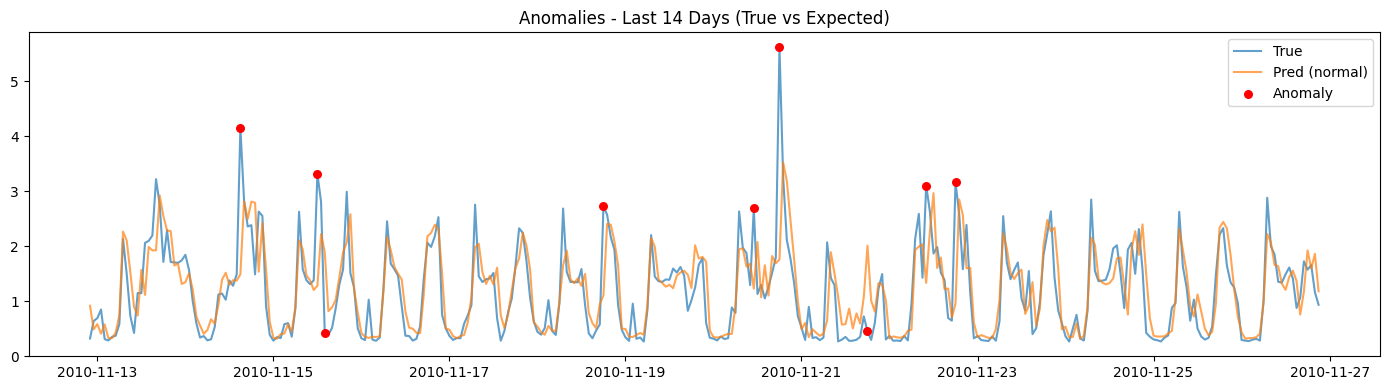

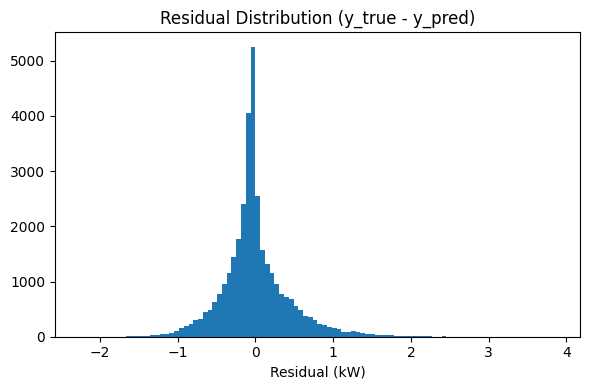

In [13]:
plot_df = df_t.last('14D')

plt.figure(figsize=(14,4))
plt.plot(plot_df.index, plot_df[target], label='True', alpha=0.7)
plt.plot(plot_df.index, plot_df['y_pred'], label='Pred (normal)', alpha=0.7)
anoms = plot_df[plot_df['is_anomaly']]
plt.scatter(anoms.index, anoms[target], c='red', s=30, label='Anomaly', zorder=5)
plt.legend()
plt.title('Anomalies - Last 14 Days (True vs Expected)')
plt.tight_layout()
plt.savefig(FIG_DIR / "anomaly_14d.png", dpi=150)
plt.show()
# Residual histogram
plt.figure(figsize=(6,4))
plt.hist(df_t['residual'].dropna(), bins=100)
plt.title('Residual Distribution (y_true - y_pred)')
plt.xlabel('Residual (kW)')
plt.tight_layout()
plt.savefig(FIG_DIR / "anomaly_residual_hist.png", dpi=150)
plt.show()

## 6. Save Anomaly Report
Sorted by **absolute error** (most severe first). The `message` column is saved too, so notebook 05 and the dashboard can display human-readable explanations..


In [14]:
report = (
    df_t[df_t['is_anomaly']][[target, 'y_pred', 'residual', 'z_score',
                              'abs_error', 'hour', 'dayofweek', 'message']]
    .sort_values('abs_error', ascending=False)
)

report.to_csv(RESULTS_DIR / "anomaly_report.csv")
print(f"Saved anomaly report: {len(report)} anomalies -> {RESULTS_DIR / 'anomaly_report.csv'}")

print("\nTop 10 most severe anomaly messages:")
for m in report['message'].head(10):
    print(" •", m)

report.head(10)

Saved anomaly report: 1286 anomalies -> reports/results/anomaly_report.csv

Top 10 most severe anomaly messages:
 • [2010-11-20 18:00] Unusual spike on Sat 18:00 (evening peak) detected by residual z-score: actual 5.63 kW vs expected 1.76 kW (Δ +3.87 kW, |z|=6.76). Possible causes: more high-power appliances running at once than usual.
 • [2010-02-21 11:00] Unusual spike on Sun 11:00 (daytime) detected by residual z-score: actual 5.09 kW vs expected 1.32 kW (Δ +3.77 kW, |z|=5.88). Possible causes: a large appliance running outside its usual schedule, or overlapping medium loads.
 • [2010-01-23 18:00] Unusual spike on Sat 18:00 (evening peak) detected by residual z-score: actual 5.27 kW vs expected 1.75 kW (Δ +3.51 kW, |z|=6.00). Possible causes: more high-power appliances running at once than usual.
 • [2009-01-24 11:00] Unusual spike on Sat 11:00 (daytime) detected by residual z-score: actual 5.07 kW vs expected 2.03 kW (Δ +3.05 kW, |z|=6.39). Possible causes: a large appliance runnin

,Global_active_power,y_pred,residual,z_score,abs_error,hour,dayofweek,message
datetime,,,,,,,,
2010-11-20 18:00:00,5.626833,1.759328,3.867505,6.760326,3.867505,18,5,[2010-11-20 18:00] Unusual spike on Sat 18:00 ...
2010-02-21 11:00:00,5.090800,1.320459,3.770341,5.884112,3.770341,11,6,[2010-02-21 11:00] Unusual spike on Sun 11:00 ...
2010-01-23 18:00:00,5.265533,1.752495,3.513039,5.998219,3.513039,18,5,[2010-01-23 18:00] Unusual spike on Sat 18:00 ...
2009-01-24 11:00:00,5.073400,2.027934,3.045466,6.390545,3.045466,11,5,[2009-01-24 11:00] Unusual spike on Sat 11:00 ...
2009-10-23 15:00:00,4.025300,1.046344,2.978956,5.147501,2.978956,15,4,[2009-10-23 15:00] Unusual spike on Fri 15:00 ...
2010-01-15 20:00:00,5.336800,2.368543,2.968257,5.168131,2.968257,20,4,[2010-01-15 20:00] Unusual spike on Fri 20:00 ...
2009-11-24 19:00:00,4.505600,1.669181,2.836419,4.715235,2.836419,19,1,[2009-11-24 19:00] Unusual spike on Tue 19:00 ...
2007-05-08 12:00:00,4.719133,1.932178,2.786955,5.607731,2.786955,12,1,[2007-05-08 12:00] Unusual spike on Tue 12:00 ...
2009-10-24 18:00:00,3.998867,1.314854,2.684013,4.303101,2.684013,18,5,[2009-10-24 18:00] Unusual spike on Sat 18:00 ...


## 7. Key findings for next phase

- **Anomaly rate ~2-4%** is normal for household data.

- **Residual method** catches point anomalies: sudden spikes where actual >> predicted (e.g., oven + AC left on).

- **Isolation Forest** catches contextual anomalies: high consumption at 3 AM (unusual hour).

- **Z-score > 3** is adaptive threshold, better than fixed kW threshold because it adjusts to volatility.

- Every anomaly carries a general `message` describing:
  - the type of deviation (spike / drop),
  - the period of day (overnight / morning / daytime / evening peak / late evening),
  - which detector flagged it,
  - a short list of **possible causes to check** — worded as candidates, never as a definite appliance.


- **Next:** 05_recommendation_system.ipynb will use
residual and
hour to suggest savings (e.g., "Shift usage from 20h to 14h").